# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Load data
df = pd.read_csv('data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [3]:
# Check for missing values (this dataset encodes unknowns as the string 'unknown' rather than NaN)
print('True NaNs per column:')
print(df.isnull().sum().sum())

print('\n"unknown" counts per categorical column:')
for col in df.select_dtypes(include='object').columns:
    unk = (df[col] == 'unknown').sum()
    if unk > 0:
        print(f'  {col}: {unk} ({unk/len(df)*100:.1f}%)')

True NaNs per column:
0

"unknown" counts per categorical column:
  job: 330 (0.8%)
  marital: 80 (0.2%)
  education: 1731 (4.2%)
  default: 8597 (20.9%)
  housing: 990 (2.4%)
  loan: 990 (2.4%)


/tmp/ipykernel_651/404932833.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


## Customer Demographics Analysis

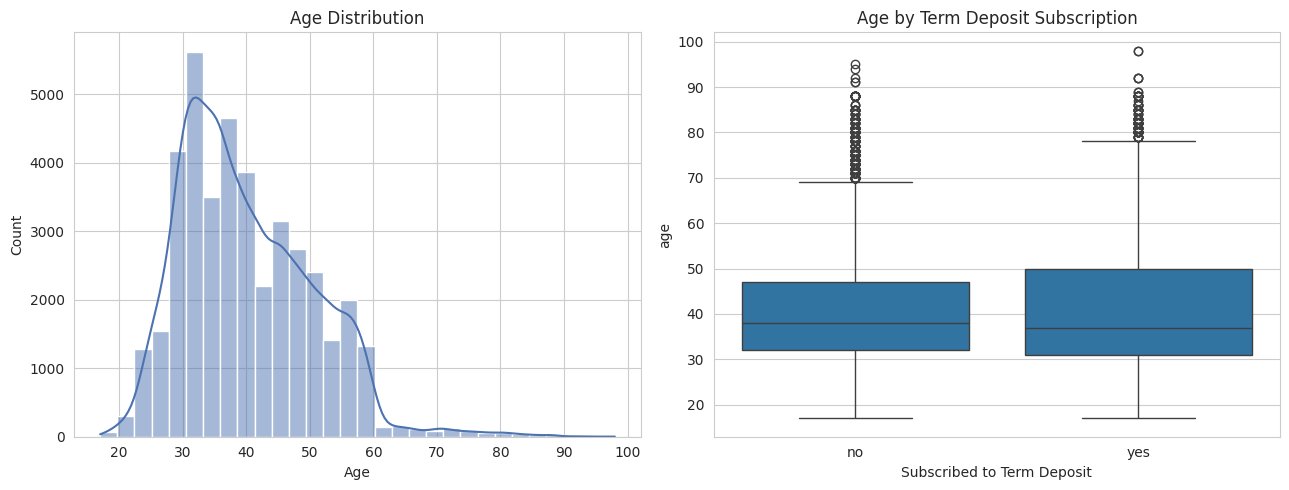

In [4]:
# Age distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df['age'], bins=30, kde=True, color='#4C72B0', ax=axes[0])
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

sns.boxplot(data=df, x='y', y='age', ax=axes[1])
axes[1].set_title('Age by Term Deposit Subscription')
axes[1].set_xlabel('Subscribed to Term Deposit')

plt.tight_layout()
plt.show()

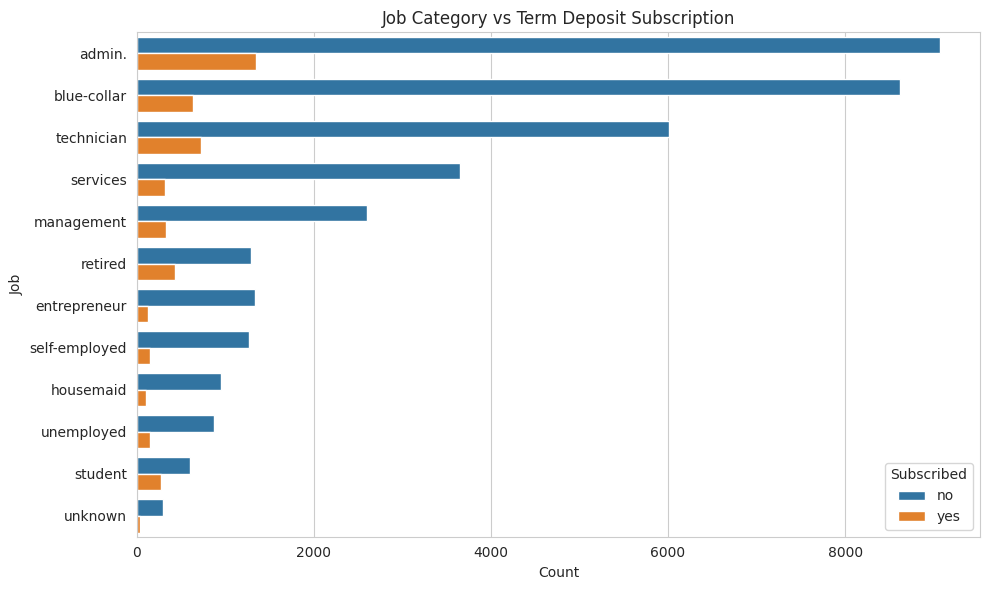

Subscription rate by job:
job
student          0.314286
retired          0.252326
unemployed       0.142012
admin.           0.129726
management       0.112175
unknown          0.112121
technician       0.108260
self-employed    0.104856
housemaid        0.100000
entrepreneur     0.085165
services         0.081381
blue-collar      0.068943
Name: y, dtype: float64


In [5]:
# Job distribution
plt.figure(figsize=(10, 6))
job_order = df['job'].value_counts().index
sns.countplot(data=df, y='job', order=job_order, hue='y')
plt.title('Job Category vs Term Deposit Subscription')
plt.xlabel('Count')
plt.ylabel('Job')
plt.legend(title='Subscribed')
plt.tight_layout()
plt.show()

# Subscription rate by job (more informative than raw counts, since job group sizes vary a lot)
job_rate = df.groupby('job')['y'].apply(lambda s: (s == 'yes').mean()).sort_values(ascending=False)
print('Subscription rate by job:')
print(job_rate)

## Balance & Deposit Trends
Note: this version of the dataset (the UCI *bank-additional-full* variant) does not include an account **balance** column. Instead, we look at **call duration** and macro-economic indicators, which are the closest available signals of the customer's engagement and financial context in this dataset.

Average call duration (seconds) by subscription outcome:
y
no     220.844807
yes    553.191164
Name: duration, dtype: float64


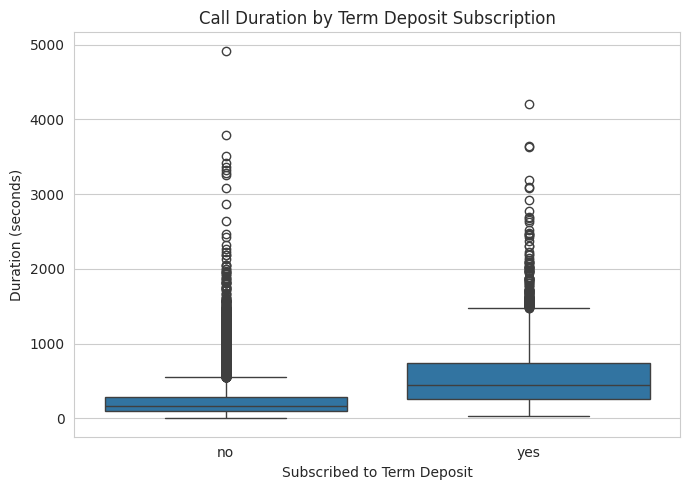


Note: duration is only known *after* the call ends, so it should not be used as an input
feature for a realistic model that predicts subscription *before* calling. It is shown here
for exploratory purposes and excluded from the predictive model below.


In [6]:
# Average call duration by deposit subscription
duration_by_y = df.groupby('y')['duration'].mean()
print('Average call duration (seconds) by subscription outcome:')
print(duration_by_y)

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='y', y='duration')
plt.title('Call Duration by Term Deposit Subscription')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Duration (seconds)')
plt.tight_layout()
plt.show()

print('\nNote: duration is only known *after* the call ends, so it should not be used as an input\n'
      'feature for a realistic model that predicts subscription *before* calling. It is shown here\n'
      'for exploratory purposes and excluded from the predictive model below.')

## Campaign Effectiveness

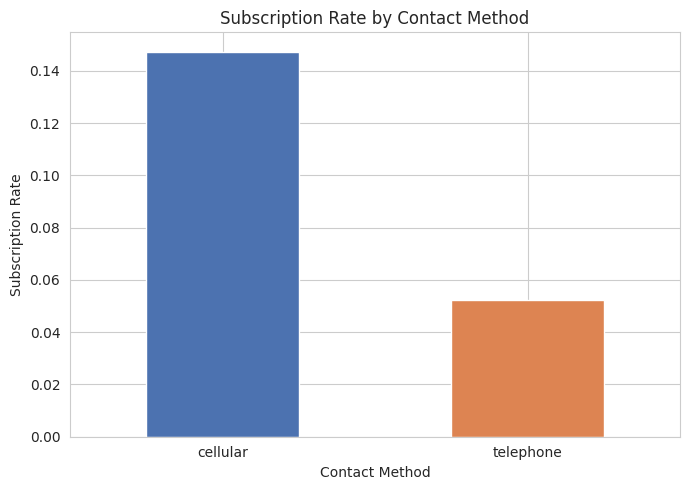

contact
cellular     0.147376
telephone    0.052313
Name: y, dtype: float64


In [7]:
# Contact method analysis
plt.figure(figsize=(7, 5))
contact_rate = df.groupby('contact')['y'].apply(lambda s: (s == 'yes').mean())
contact_rate.plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Subscription Rate by Contact Method')
plt.xlabel('Contact Method')
plt.ylabel('Subscription Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(contact_rate)

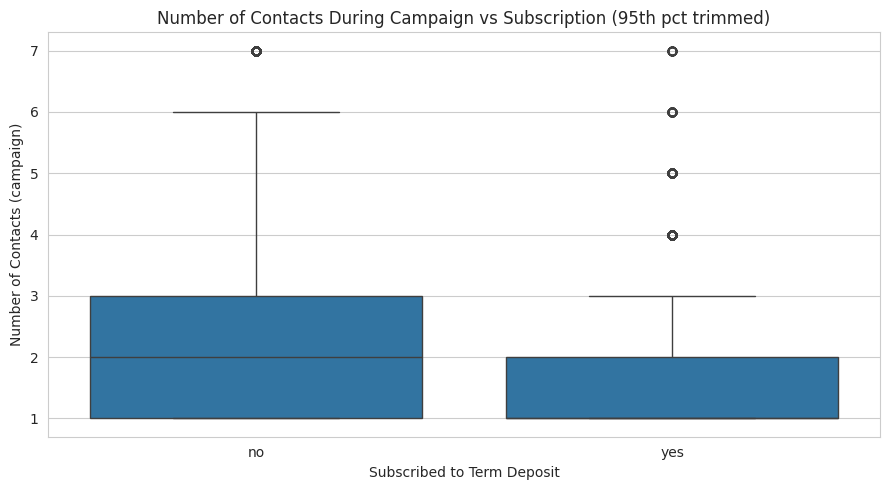

Average number of contacts by subscription outcome:
y
no     2.633085
yes    2.051724
Name: campaign, dtype: float64


In [8]:
# Number of contacts vs deposit subscription
plt.figure(figsize=(9, 5))
sns.boxplot(data=df[df['campaign'] <= df['campaign'].quantile(0.95)], x='y', y='campaign')
plt.title('Number of Contacts During Campaign vs Subscription (95th pct trimmed)')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Number of Contacts (campaign)')
plt.tight_layout()
plt.show()

print('Average number of contacts by subscription outcome:')
print(df.groupby('y')['campaign'].mean())

## Correlation Heatmap

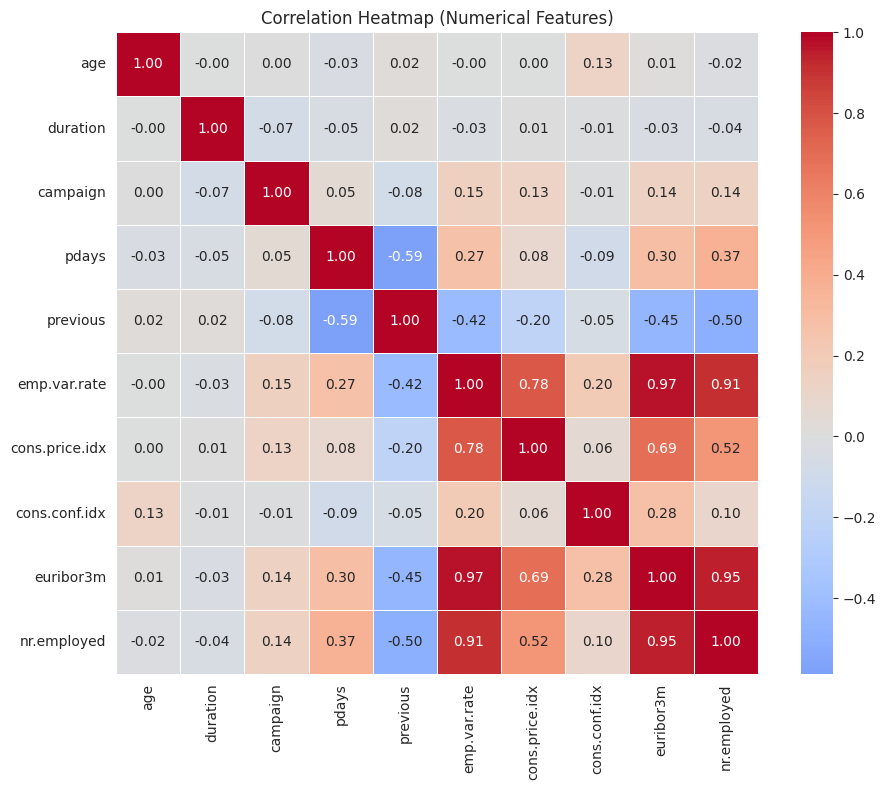

In [9]:
# Correlation of numerical variables
plt.figure(figsize=(10, 8))
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap (Numerical Features)')
plt.tight_layout()
plt.show()

## Predictive Modeling (Logistic Regression)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, RocCurveDisplay

# Encode categorical variables
df_model = df.copy()

# Drop 'duration' to avoid data leakage (it's only known after the call takes place)
df_model = df_model.drop(columns=['duration'])

# Encode target
df_model['y'] = df_model['y'].map({'no': 0, 'yes': 1})

# One-hot encode remaining categorical features
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

X = df_model.drop(columns=['y'])
y = df_model['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression (class_weight='balanced' since only ~11% of customers subscribe)
model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

/tmp/ipykernel_651/803308048.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_model.select_dtypes(include='object').columns.tolist()


Accuracy: 0.8348
ROC AUC: 0.8009

Classification Report:
              precision    recall  f1-score   support

          No       0.95      0.86      0.90      7310
         Yes       0.37      0.64      0.47       928

    accuracy                           0.83      8238
   macro avg       0.66      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238



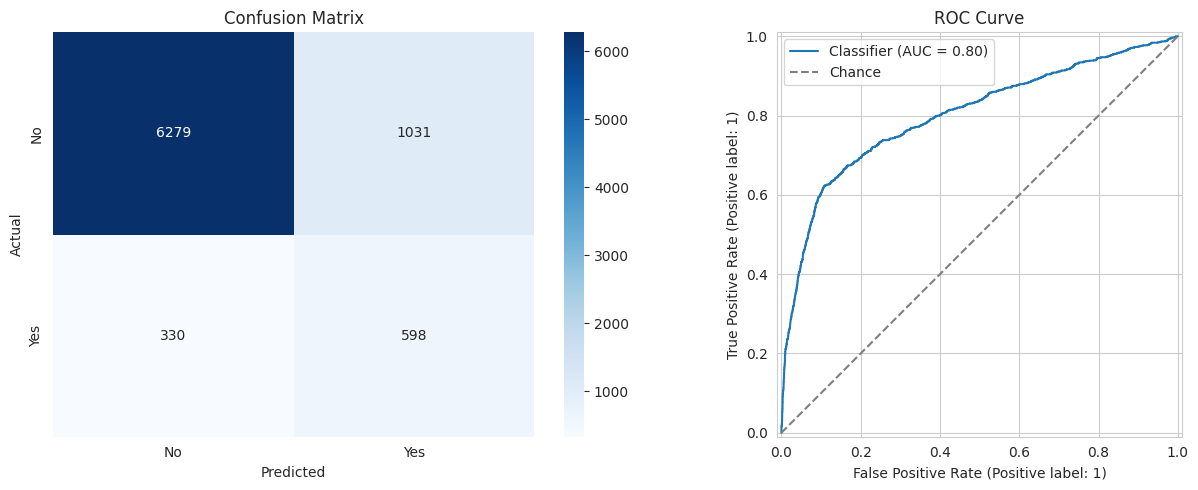

In [11]:
# Confusion matrix and ROC curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

## Feature Importance

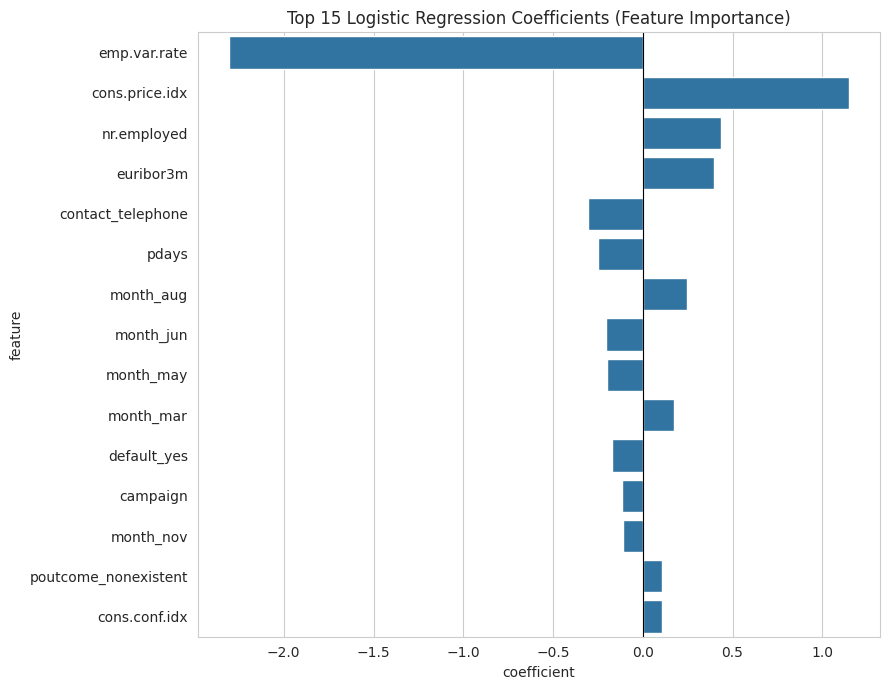

,feature,coefficient
4,emp.var.rate,-2.306255
5,cons.price.idx,1.148698
8,nr.employed,0.438281
7,euribor3m,0.397288
36,contact_telephone,-0.307892
2,pdays,-0.249684
37,month_aug,0.248707
40,month_jun,-0.203474
42,month_may,-0.200585
41,month_mar,0.175135


In [12]:
# Feature importance
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(data=coef_df, x='coefficient', y='feature')
plt.title('Top 15 Logistic Regression Coefficients (Feature Importance)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

coef_df

## Key Takeaways
- Certain age groups and job categories (e.g., students and retirees) are more likely to subscribe.
- This dataset version has no account balance field; call duration and macro-economic context (e.g., `euribor3m`, `nr.employed`) serve as the closest available signals, though duration is excluded from the model to avoid leakage.
- Cellular contact is associated with a meaningfully higher subscription rate than telephone.
- A higher number of contacts during the campaign is generally associated with *lower* success, suggesting diminishing (or negative) returns to repeated contact attempts.
- Logistic regression (with `class_weight='balanced'` to account for the ~11%/89% class imbalance) shows previous campaign outcome (`poutcome`), macro-economic indicators, and contact method among the strongest predictors of subscription.